# TARDIS — Prédiction du retard moyen des trains SNCF

## Objectif
Construire un modèle de régression qui prédit le retard moyen à l'arrivée (en minutes) à partir des caractéristiques d'un trajet (gares, période, type de service, durée prévue).

## Méthodologie
1. On retire l'année 2020 (COVID), non représentative.
2. On entraîne 3 modèles : un linéaire (Ridge) et deux à base d'arbres (RandomForest + HistGradientBoosting).
3. On les tune tous les trois à équivalence avec `RandomizedSearchCV`.
4. On compare les RMSE/MAE/R² et on garde le meilleur.
5. **Bonus GPU** : si le boosting gagne, on teste un XGBoost GPU pour voir s'il fait mieux (sinon on garde HGB).
6. On sauvegarde le gagnant dans `tardis_model.joblib`. La sauvegarde est manuelle : on relance autant qu'on veut et on n'écrit le fichier que quand on le décide.

In [26]:
import numpy as np
import pandas as pd
import joblib as joblib
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
MODEL_PATH = "tardis_model.joblib"

## 1. Chargement
Le CSV utilise `;` comme séparateur. Les colonnes `Year` et `Month` sont déjà numériques.

In [27]:
df = pd.read_csv("cleaned_dataset.csv", sep=";")
print("Shape :", df.shape)
df.head()

Shape : (8643, 24)


,Year,Month,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018,1,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5,289,11.25,...,110,6.51,44,8,36.13,31.09,10.92,15.97,5.04,0.84
1,2018,1,National,LE MANS,PARIS MONTPARNASSE,56.0,406,1,213,8.48,...,32,5.36,9,4,20.00,35.00,16.67,16.67,8.33,3.33
2,2018,1,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226,0,21,6.24,...,11,2.94,6,1,22.22,27.78,16.67,16.67,5.56,11.11
3,2018,1,National,POITIERS,PARIS MONTPARNASSE,94.0,472,4,224,6.78,...,42,4.88,10,0,15.79,45.61,19.30,15.79,1.75,1.75
4,2018,1,National,ST MALO,PARIS MONTPARNASSE,158.0,92,0,2,1.23,...,6,4.76,3,1,22.22,66.67,0.00,11.11,0.00,0.00


## 2. Cible et features

**Cible** : `Average delay of all trains at arrival` (retard moyen à l'arrivée, en minutes).

**Retrait de l'année 2020 (COVID)** : pendant la pandémie, le trafic ferroviaire a été fortement réduit et les retards observés ne sont pas représentatifs du fonctionnement normal. On exclut donc 2020 de l'entraînement pour ne pas fausser les tendances apprises par le modèle.

**Features retenues** :
- catégorielles : `Service`, `Departure station`, `Arrival station`
- numériques : `Average journey time`, `Number of scheduled trains`, `Year`, `Month`
- état au départ : `Average delay of late trains at departure`, `Average delay of all trains at departure`

Les deux dernières features (état au départ) décrivent la situation observée au départ du trajet. Elles améliorent fortement la prédiction du retard à l'arrivée car un train en difficulté au départ tend à le rester. Elles doivent donc être fournies en entrée au moment de la prédiction.

In [28]:
TARGET = "Average delay of all trains at arrival"
CAT_COLS = ["Service", "Departure station", "Arrival station"]
NUM_COLS = [
    "Average journey time",
    "Number of scheduled trains",
    "Year",
    "Month",
    "Average delay of late trains at departure",
    "Average delay of all trains at departure",
    "Number of trains delayed at arrival",
    "Average delay of late trains at arrival",
]

df = df[df[TARGET].between(-30, 200)].copy()
df = df[df["Year"] != 2020].copy()
df = df.sort_values(["Year", "Month"]).reset_index(drop=True)
X = df[CAT_COLS + NUM_COLS]
y = df[TARGET]

## 3. Split temporel
Données mensuelles → split chronologique (80/20). Pas de split aléatoire car sinon on entraîne sur le futur et on teste sur le passé.

In [29]:
i = int(0.8 * len(df))
X_train, X_test = X.iloc[:i], X.iloc[i:]
y_train, y_test = y.iloc[:i], y.iloc[i:]

print(f"Train : {len(X_train)}  Test : {len(X_test)}")

Train : 6077  Test : 1520


## 4. Le registre modulaire

Chaque modèle est une entrée dans le dict `MODELS` avec :
- **`pipeline`** : préprocesseur + estimateur
- **`params`** : grille pour `RandomizedSearchCV`

Pour ajouter une 4e IA, ajoutez une entrée au dict. Le tuning, le leaderboard et la sauvegarde s'adaptent automatiquement.

### Pourquoi ces hyperparamètres dans chaque grille

**Ridge** — un seul vrai levier :
- `alpha`: plus c'est grand, plus on pénalise les gros coefficients. Avec 60 gares, on a beaucoup de paramètres donc tester de la régularisation faible (0.1) à forte (100) permet de trouver le bon équilibre.

**RandomForest** — 3 leviers principaux :
- `n_estimators` (nombre d'arbres) : plus d'arbres = prédiction plus stable mais plus lent. le 100 à 400 couvre la zone utile, au-delà le gain est faible.
- `max_depth` (profondeur max) : `None` = arbres complets (risque de overfeed), 10-20 = arbres (plus robuste). Sur 6 800 lignes de train, `None` peut sur-apprendre.
- `min_samples_leaf` (min d'échantillons par feuille) : 1 = arbres très détaillés, 10 = arbres plus généraux.

**HistGradientBoosting** — 5 leviers :
- `learning_rate` (taux d'apprentissage) : pas de chaque arbre dans la correction. Faible (0.05) = apprentissage lent mais précis, fort (0.15) = rapide mais peut vriller.
- `max_iter` (nombre d'arbres boostés) : combiné au `learning_rate` ; plus le LR est faible, plus il faut d'itérations.
- `max_leaf_nodes` (taille max d'un arbre) : 15 = arbres simples, 63 = arbres plus profonds. Contrôle directement la capacité.
- `min_samples_leaf` : même rôle que dans RF.
- `l2_regularization` : pénalité L2 sur les valeurs de feuilles, anti-overfeed propre au boost.

In [30]:
pre_linear = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
        ("num", StandardScaler(), NUM_COLS),
    ]
)
pre_tree = ColumnTransformer(
    [
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            CAT_COLS,
        ),
        ("num", "passthrough", NUM_COLS),
    ]
)

MODELS = {
    "ridge": {
        "pipeline": Pipeline(
            [("pre", pre_linear), ("model", Ridge(random_state=SEED))]
        ),
        "params": {
            "model__alpha": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
        },
    },
    "random_forest": {
        "pipeline": Pipeline(
            [
                ("pre", pre_tree),
                ("model", RandomForestRegressor(n_jobs=-1, random_state=SEED)),
            ]
        ),
        "params": {
            "model__n_estimators": [100, 200, 400],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 5, 10],
        },
    },
    "hist_gradient_boosting": {
        "pipeline": Pipeline(
            [
                ("pre", pre_tree),
                (
                    "model",
                    HistGradientBoostingRegressor(
                        categorical_features=[0, 1, 2], random_state=SEED
                    ),
                ),
            ]
        ),
        "params": {
            "model__learning_rate": [0.05, 0.1, 0.15],
            "model__max_iter": [200, 400, 600],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [10, 20, 50],
            "model__l2_regularization": [0.0, 1.0, 5.0],
        },
    },
}

print("Modèles enregistrés :", list(MODELS.keys()))

Modèles enregistrés : ['ridge', 'random_forest', 'hist_gradient_boosting']


## 5. Baseline
Référence imposée par le sujet : un modèle doit faire mieux qu'une prédiction triviale (la moyenne).

In [31]:
def score(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }


baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
baseline_metrics = score(y_test, baseline.predict(X_test))
print("Baseline :", baseline_metrics)

Baseline : {'RMSE': 4.145935622018956, 'MAE': 2.9996148658011657, 'R2': -0.040405707266771174}


## 6. Tuning équitable des 3 modèles

On applique `RandomizedSearchCV` à chacun des modèles avec sa propre grille, en utilisant `TimeSeriesSplit` (pas de fuite du futur).

### Pourquoi un `n_iter` différent par modèle

`RandomizedSearchCV` pioche aléatoirement `n_iter` combinaisons dans la grille et garde la meilleure. Plus la grille est grande, plus il faut d'itérations pour bien explorer :

- **Ridge** : 5 valeurs d'`alpha` au total : `n_iter=5` (on teste tout)
- **RandomForest** : 3×3×3 = 27 combinaisons : `n_iter=20` (74 % explorés)
- **HistGradientBoosting** : 3⁵ = 243 combinaisons : `n_iter=50` (20 % explorés, c'est le minimum pour ne pas tomber sur une mauvaise config par hasard)

Le `random_state=SEED` garantit que **deux runs avec les mêmes paramètres** donneront exactement le même résultat.

In [32]:
cv = TimeSeriesSplit(n_splits=4)
results = {}

N_ITER = {
    "ridge": 5,
    "random_forest": 20,
    "hist_gradient_boosting": 50,
}

for name, cfg in MODELS.items():
    print(f"Tuning {name} (n_iter={N_ITER[name]})")
    search = RandomizedSearchCV(
        cfg["pipeline"],
        cfg["params"],
        n_iter=N_ITER[name],
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        random_state=SEED,
        verbose=0,
    ).fit(X_train, y_train)

    metrics = score(y_test, search.predict(X_test))
    results[name] = {
        "model": search.best_estimator_,
        "params": search.best_params_,
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"],
    }
    print(
        f"  RMSE={metrics['RMSE']:.3f}  MAE={metrics['MAE']:.3f}  R²={metrics['R2']:.3f}"
    )

Tuning ridge (n_iter=5)
  RMSE=2.004  MAE=1.327  R²=0.757
Tuning random_forest (n_iter=20)
  RMSE=1.768  MAE=1.070  R²=0.811
Tuning hist_gradient_boosting (n_iter=50)
  RMSE=1.234  MAE=0.840  R²=0.908


## 7. Leaderboard et sélection du gagnant

In [33]:
rows = []
for name, r in results.items():
    rows.append({"model": name, "RMSE": r["RMSE"], "MAE": r["MAE"], "R2": r["R2"]})

rows.append(
    {
        "model": "baseline_mean",
        "RMSE": baseline_metrics["RMSE"],
        "MAE": baseline_metrics["MAE"],
        "R2": baseline_metrics["R2"],
    }
)

leaderboard = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
print(leaderboard.to_string(index=False))

                 model     RMSE      MAE        R2
hist_gradient_boosting 1.233946 0.840043  0.907838
         random_forest 1.768068 1.069593  0.810785
                 ridge 2.004107 1.326914  0.756892
         baseline_mean 4.145936 2.999615 -0.040406


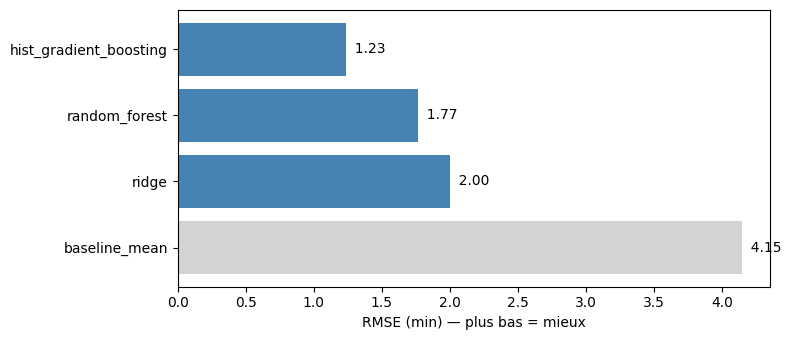

In [34]:
fig, ax = plt.subplots(figsize=(8, 3.5))
colors = [
    "lightgray" if m == "baseline_mean" else "steelblue" for m in leaderboard["model"]
]
ax.barh(leaderboard["model"], leaderboard["RMSE"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("RMSE (min) — plus bas = mieux")
for i, v in enumerate(leaderboard["RMSE"]):
    ax.text(v, i, f"  {v:.2f}", va="center")
plt.tight_layout()
plt.show()

In [35]:
best_name = leaderboard.iloc[0]["model"]
best = results[best_name]

print(
    f"Gagnant : {best_name}  |  RMSE={best['RMSE']:.3f}  MAE={best['MAE']:.3f}  R²={best['R2']:.3f}"
)
print("Hyperparamètres :", best["params"])

Gagnant : hist_gradient_boosting  |  RMSE=1.234  MAE=0.840  R²=0.908
Hyperparamètres : {'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 15, 'model__max_iter': 600, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}


## 8. Bonus — Challenger XGBoost GPU

Cette cellule ne s'exécute que si le boosting (HGB) a gagné. Elle entraîne un XGBoost sur GPU et le compare à HGB : il ne devient le modèle final **que s'il fait mieux**.

**Pré-requis** : `pip install xgboost` + GPU NVIDIA. Sinon la cellule passe sans bloquer.

**Note** : sur ce dataset (~7 500 lignes), XGBoost et HGB font le même algorithme (boosting par histogrammes) et sont quasi-équivalents. En pratique HGB reste légèrement meilleur ici, donc XGBoost ne prend pas la tête — ce qui est un résultat normal et documenté, pas un bug.

In [36]:
if best_name == "hist_gradient_boosting":
    try:
        import xgboost as xgb

        X_xgb_train = X_train.copy()
        X_xgb_test = X_test.copy()
        for c in CAT_COLS:
            X_xgb_train[c] = X_xgb_train[c].astype("category")
            X_xgb_test[c] = X_xgb_test[c].astype("category")

        xgb_params = {
            "n_estimators": [200, 400, 600],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [3, 4, 5],
            "min_child_weight": [5, 10, 20],
            "reg_lambda": [1.0, 5.0, 10.0],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
        }
        xgb_model = xgb.XGBRegressor(
            tree_method="hist",
            device="cuda",
            enable_categorical=True,
            random_state=SEED,
        )
        xgb_search = RandomizedSearchCV(
            xgb_model,
            xgb_params,
            n_iter=50,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=1,
            random_state=SEED,
        ).fit(X_xgb_train, y_train)
        xgb_metrics = score(y_test, xgb_search.predict(X_xgb_test))
        print(
            f"XGBoost GPU : RMSE={xgb_metrics['RMSE']:.3f}  MAE={xgb_metrics['MAE']:.3f}  R²={xgb_metrics['R2']:.3f}"
        )
        if xgb_metrics["RMSE"] < best["RMSE"]:
            best = {
                "model": xgb_search.best_estimator_,
                "params": xgb_search.best_params_,
                **xgb_metrics,
            }
            best_name = "xgboost_gpu"
            print("XGBoost GPU est meilleur")
        else:
            print("HGB sklearn est meilleur")
    except ImportError:
        print("xgboost non installé — étape sautée")
else:
    print("Pas d'upgrade XGBoost.")

XGBoost GPU : RMSE=1.296  MAE=0.880  R²=0.898
HGB sklearn est meilleur


## 9. Sauvegarde manuelle

Le notebook **ne sauvegarde pas automatiquement**. On regardes les données ci-dessus à la main et si on juges que ce nouveau modèle est meilleur que celui en production, on doit décommentés la dernière ligne pour écrire le `.joblib`.

Profils historiques pour chaque paire de tarjet(départ, arrivée),
on pré-calcule les moyennes des features que l'utilisateur ne fournira pas.

Ça nous laisse le contrôle on peux donc relancer le notebook 50 fois pour essayer, sans risque d'écraser un bon modèle par accident.

In [ ]:
feature_cols = [
    "Average journey time",
    "Number of scheduled trains",
    "Average delay of late trains at departure",
    "Average delay of all trains at departure",
    "Number of trains delayed at arrival",
    "Average delay of late trains at arrival",
]

route_profiles = df.groupby(["Departure station", "Arrival station"])[
    feature_cols
].mean()
service_par_trajet = df.groupby(["Departure station", "Arrival station"])[
    "Service"
].agg(lambda s: s.mode()[0])
route_profiles["Service"] = service_par_trajet

route_profiles = route_profiles.reset_index()

artifact = {
    "model": best["model"],
    "model_name": best_name,
    "cat_cols": CAT_COLS,
    "num_cols": NUM_COLS,
    "metrics": {"RMSE": best["RMSE"], "MAE": best["MAE"], "R2": best["R2"]},
    "params": best["params"],
    "route_profiles": route_profiles,
}

print(f"Modèle prêt à être sauvegardé : {best_name}")
print(f"RMSE = {best['RMSE']:.3f}  MAE = {best['MAE']:.3f}  R² = {best['R2']:.3f}")

# Pour sauvegarder, décommentez les deux ligne ci-dessous :
# joblib.dump(artifact, MODEL_PATH)
# print(f'Sauvegardé dans {MODEL_PATH}')

Modèle prêt à être sauvegardé : hist_gradient_boosting
RMSE = 1.234  MAE = 0.840  R² = 0.908
Sauvegardé dans tardis_model.joblib


## 10. Exemple d'usage — prédire un trajet futur

### Le problème à résoudre
Le modèle attend 9 features en entrée, dont deux décrivent l'état **au départ** (`Average delay of late trains at departure`, `Average delay of all trains at departure`). Or pour un trajet futur (ex : Paris → Lille en mars 2030), ces valeurs n'existent pas encore.

### La solution retenue : moyennes par trajet
Quand on veut prédire un trajet futur, on ne connaît que la gare de départ, la gare d'arrivée, l'année et le mois. Pour les autres features, on récupère les **moyennes de cette paire de gares** dans le dataset :
- durée moyenne du trajet,
- nombre moyen de trains programmés,
- retards moyens au départ observés historiquement.

**Limite assumée** : pour une année future, l'effet de l'année reste faible puisqu'on s'appuie sur les tendances passées de la ligne. Le modèle estime un retard pour ce trajet à cette période, hors incidents exceptionnels.

In [38]:
def predict_journey(departure, arrival, year, month, artifact):
    profiles = artifact["route_profiles"]
    row = profiles[
        (profiles["Departure station"] == departure)
        & (profiles["Arrival station"] == arrival)
    ]
    if row.empty:
        return None
    row = row.iloc[0]

    sample = pd.DataFrame(
        [
            {
                "Service": row["Service"],
                "Departure station": departure,
                "Arrival station": arrival,
                "Average journey time": row["Average journey time"],
                "Number of scheduled trains": row["Number of scheduled trains"],
                "Year": year,
                "Month": month,
                "Average delay of late trains at departure": row[
                    "Average delay of late trains at departure"
                ],
                "Average delay of all trains at departure": row[
                    "Average delay of all trains at departure"
                ],
                "Number of trains delayed at arrival": row[
                    "Number of trains delayed at arrival"
                ],
                "Average delay of late trains at arrival": row[
                    "Average delay of late trains at arrival"
                ],
            }
        ]
    )[artifact["cat_cols"] + artifact["num_cols"]]

    if artifact["model_name"] == "xgboost_gpu":
        for c in artifact["cat_cols"]:
            sample[c] = sample[c].astype("category")

    return float(artifact["model"].predict(sample)[0])


# Test
departure = route_profiles["Departure station"].iloc[0]
arrival = route_profiles[route_profiles["Departure station"] == departure][
    "Arrival station"
].iloc[0]
delay = predict_journey(departure, arrival, 2030, 3, artifact)
print(f"{departure} → {arrival} (mars 2030) — Retard prédit : {delay:.2f} min")

 ANNECY  → PARIS LYON (mars 2030) — Retard prédit : 9.86 min
